# Stationarity testing of the data which is used

The sript contains the tests for all data. The scripts itself is a .py script which is loaded in the jupiter for visualization

In [1]:
from stationarity_tests import mean_variance, rolling_mean_variance, adf_kpss_test, plot_time_series, process_data, detrend_only, is_stationary, preprocess_epochs

# PBT Young 13 - stationarity ok

In [1]:

from pathlib import Path
import xarray as xr
cwd = Path.cwd()
print("Current working directory:", cwd.resolve())
data_path = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_13" / "Pre.3" / "markers.nc"
# events_path = cwd.parent / ".." / "data" / "CGA" / "04" / "PWS" / "4" / "PWS.4_events.csv"


ds = xr.open_dataset(data_path)
print("Dataset loaded. Variables:", list(ds.data_vars.keys()))

# Set parameters for your functions
data = ds['markers']
com=data.sel(channel='COM')  

dataset_name = "markers.nc"           
channel = "COM"                  
window_size = 100                
results_dir = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_13" / "stationarity_test"  
t = com.coords['time'].values
print("Time coordinates:", t)
plot_time_series(data, t, channel='COM')


# data = detrend_only(data, fs=100.0)
data  =preprocess_epochs(data, fs=100.0,epoch_length_s = 20.0, poly_order=1)

plot_time_series(data, t, channel='COM')
t = data.coords['time'].values
perturbation_start = 160.00  # Start time of perturbation in seconds
idx_baseline   =  (t >= 20.0) & (t < perturbation_start)
perturbation_end = 180.00    # End time of perturbation in seconds
idx_perturb    = (t >= perturbation_start) & (t < perturbation_end)
idx_recovery   = t >= perturbation_end
print("Baseline indices:", idx_baseline)
print("Perturbation indices:", idx_perturb)
baseline   = data.sel(time=idx_baseline)
recovery   = data.sel(time=idx_recovery)

# 2) Test stationarity only on baseline & recovery:
print("Baseline stationarity:")
adf_kpss_test(baseline,  "baseline", channel, results_dir)
print("Recovery stationarity:")
adf_kpss_test(recovery,  "recovery", channel, results_dir)

mean_variance(data, dataset_name, channel=channel)
rolling_mean_variance(data, dataset_name, channel=channel, window_size=window_size, output_dir=results_dir)



# mean_variance(data, dataset_name, channel=channel)
# rolling_mean_variance(data, dataset_name, channel=channel, window_size=window_size, output_dir=results_dir)
# adf_kpss_test(data, dataset_name, channel=channel, output_dir=results_dir)

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation


: 

# PBT 13

In [ ]:

from pathlib import Path
import xarray as xr
cwd = Path.cwd()
print("Current working directory:", cwd.resolve())
data_path = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_13" / "Pre.3" / "markers.nc"
# events_path = cwd.parent / ".." / "data" / "CGA" / "04" / "PWS" / "4" / "PWS.4_events.csv"


ds = xr.open_dataset(data_path)
print("Dataset loaded. Variables:", list(ds.data_vars.keys()))

# Set parameters for your functions
data = ds['markers']
com=data.sel(channel='COM')  

dataset_name = "markers.nc"           
channel = "COM"                  
window_size = 100                
results_dir = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_13" / "stationarity_test"  
t = com.coords['time'].values
print("Time coordinates:", t)
plot_time_series(data, t, channel='COM')


# data = detrend_only(data, fs=100.0)
data  =process_data(data, fs=100.0,
                            low_lp=10.0,
                            low_bp=0.1,
                            high_bp=11.0,
                            do_zscore= True) 

plot_time_series(data, t, channel='COM')
perturbation_start = 150.00  # Start time of perturbation in seconds
idx_baseline   =  (t >= 50.0) & (t < perturbation_start)
perturbation_end = 180.00    # End time of perturbation in seconds
idx_perturb    = (t >= perturbation_start) & (t < perturbation_end)
idx_recovery   = t >= perturbation_end
print("Baseline indices:", idx_baseline)
print("Perturbation indices:", idx_perturb)
baseline   = data.sel(time=idx_baseline)
recovery   = data.sel(time=idx_recovery)

# 2) Test stationarity only on baseline & recovery:
print("Baseline stationarity:")
adf_kpss_test(baseline,  "baseline", channel, results_dir)
print("Recovery stationarity:")
adf_kpss_test(recovery,  "recovery", channel, results_dir)

mean_variance(data, dataset_name, channel=channel)
rolling_mean_variance(data, dataset_name, channel=channel, window_size=window_size, output_dir=results_dir)



# mean_variance(data, dataset_name, channel=channel)
# rolling_mean_variance(data, dataset_name, channel=channel, window_size=window_size, output_dir=results_dir)
# adf_kpss_test(data, dataset_name, channel=channel, output_dir=results_dir)

# PBT Young 14 - stationarity ok

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Dataset loaded. Variables: ['markers']
Time coordinates: [0.0000e+00 1.0000e-02 2.0000e-02 ... 2.5570e+02 2.5571e+02 2.5572e+02]


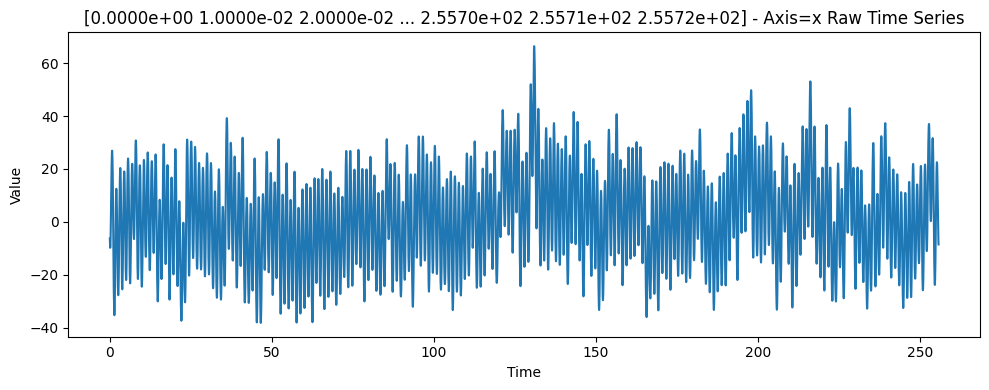

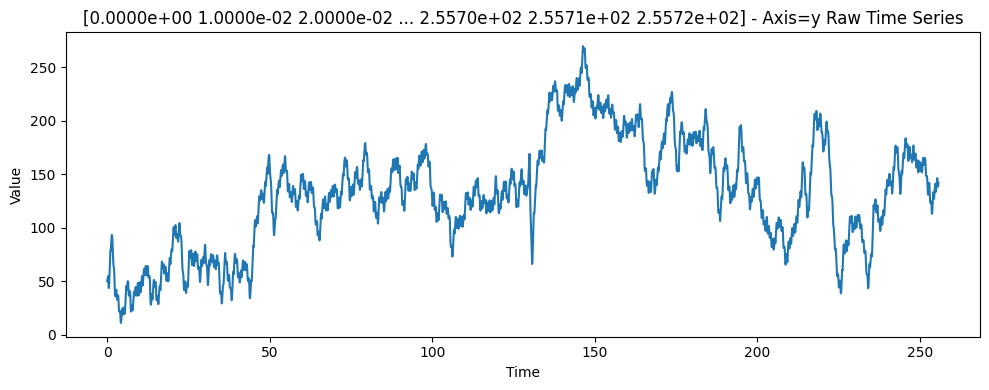

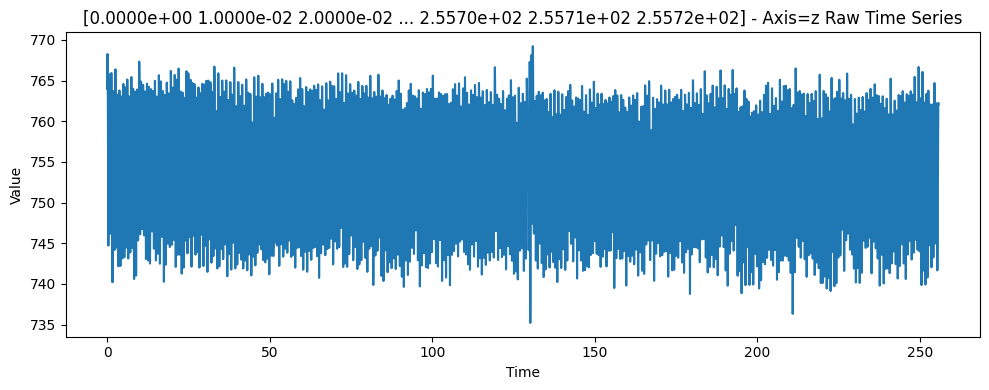

c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:195: RuntimeWarning: invalid value encountered in divide
  return (ts_bp - np.mean(ts_bp)) / np.std(ts_bp)


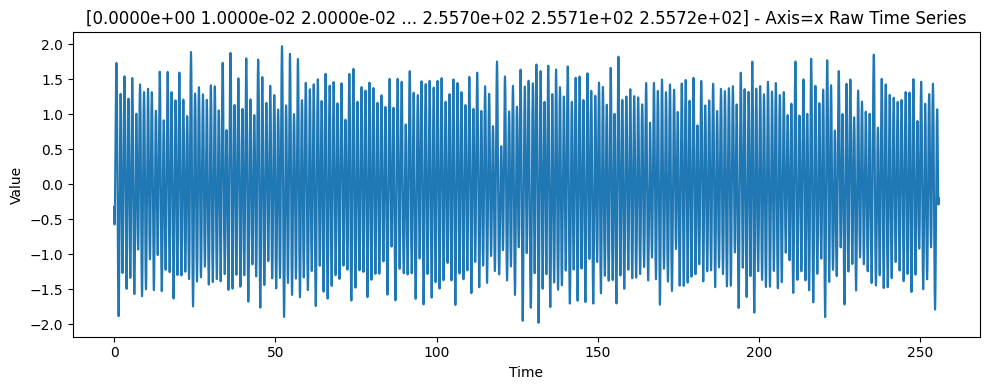

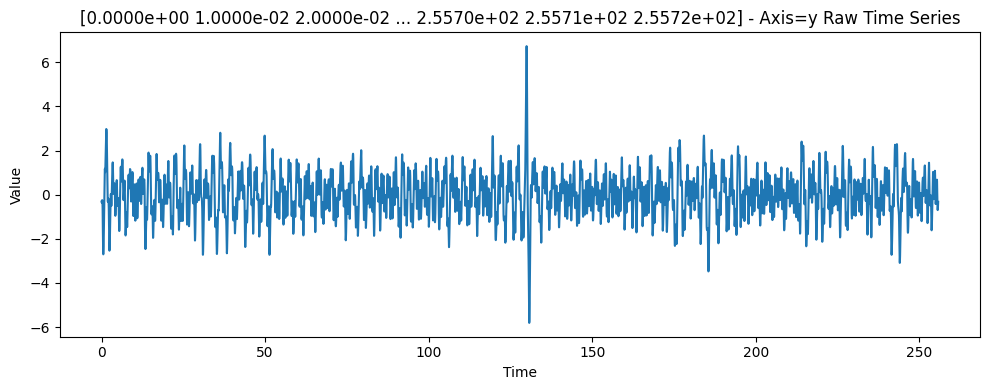

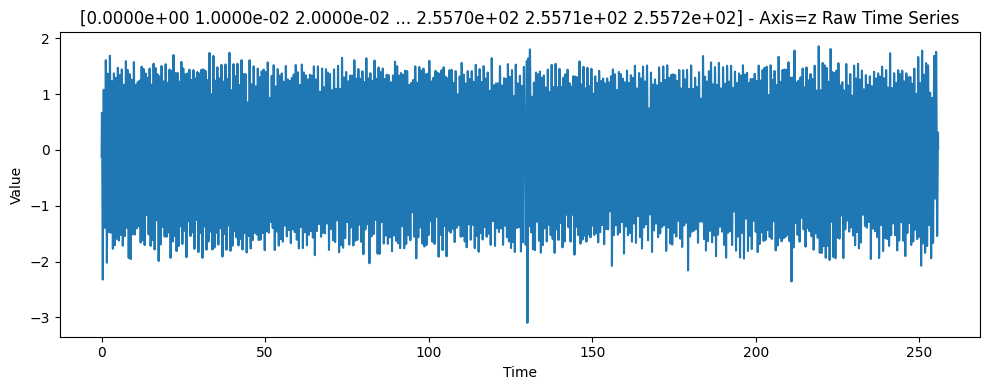

Baseline indices: [False False False ... False False False]
Perturbation indices: [False False False ... False False False]
Baseline stationarity:


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_14\stationarity_test\baseline_axisx_stationarity.txt


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_14\stationarity_test\baseline_axisy_stationarity.txt


...

Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_14\stationarity_test\recovery_axisx_stationarity.txt


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_14\stationarity_test\recovery_axisy_stationarity.txt


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_14\stationarity_test\recovery_axisz_stationarity.txt

--- Mean & Variance for markers.nc (COM) ---
Axis=x: Mean=0.0000, Variance=1.0000
Axis=y: Mean=-0.0000, Variance=1.0000
Axis=z: Mean=-0.0000, Variance=1.0000
Saved rolling plot: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_14\stationarity_test\markers.nc_axisx_rolling.png
Saved rolling plot: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_14\stationarity_test\markers.nc_axisy_rolling.png
Saved rolling plot: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_14\stationarity_test\markers.nc_axisz_rolling.png


In [21]:

from pathlib import Path
import xarray as xr
cwd = Path.cwd()
print("Current working directory:", cwd.resolve())
data_path = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_14" / "Pre.3" / "markers.nc"
# events_path = cwd.parent / ".." / "data" / "CGA" / "04" / "PWS" / "4" / "PWS.4_events.csv"


ds = xr.open_dataset(data_path)
print("Dataset loaded. Variables:", list(ds.data_vars.keys()))

# Set parameters for your functions
data = ds['markers']
com=data.sel(channel='COM')  

dataset_name = "markers.nc"           
channel = "COM"                  
window_size = 100                
results_dir = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_14" / "stationarity_test"  
t = com.coords['time'].values
print("Time coordinates:", t)
plot_time_series(data, t, channel='COM')


data = detrend_only(data, fs=100.0)
data  =process_data(data, fs=100.0,
                            low_lp=10.0,
                            low_bp=0.3,
                            high_bp=8.0,
                            do_zscore= True) 

plot_time_series(data, t, channel='COM')
perturbation_start = 110.00  # Start time of perturbation in seconds
idx_baseline   =  (t >= 50.0) & (t < perturbation_start)
perturbation_end = 150.00    # End time of perturbation in seconds
idx_perturb    = (t >= perturbation_start) & (t < perturbation_end)
idx_recovery   = t >= perturbation_end
print("Baseline indices:", idx_baseline)
print("Perturbation indices:", idx_perturb)
baseline   = data.sel(time=idx_baseline)
recovery   = data.sel(time=idx_recovery)

# 2) Test stationarity only on baseline & recovery:
print("Baseline stationarity:")
adf_kpss_test(baseline,  "baseline", channel, results_dir)
print("Recovery stationarity:")
adf_kpss_test(recovery,  "recovery", channel, results_dir)

mean_variance(data, dataset_name, channel=channel)
rolling_mean_variance(data, dataset_name, channel=channel, window_size=window_size, output_dir=results_dir)



# mean_variance(data, dataset_name, channel=channel)
# rolling_mean_variance(data, dataset_name, channel=channel, window_size=window_size, output_dir=results_dir)
# adf_kpss_test(data, dataset_name, channel=channel, output_dir=results_dir)

# PBT Young 15 - Stationarity ok 

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Dataset loaded. Variables: ['markers']
Time coordinates: [2.0000e-02 3.0000e-02 4.0000e-02 ... 2.5569e+02 2.5570e+02 2.5571e+02]


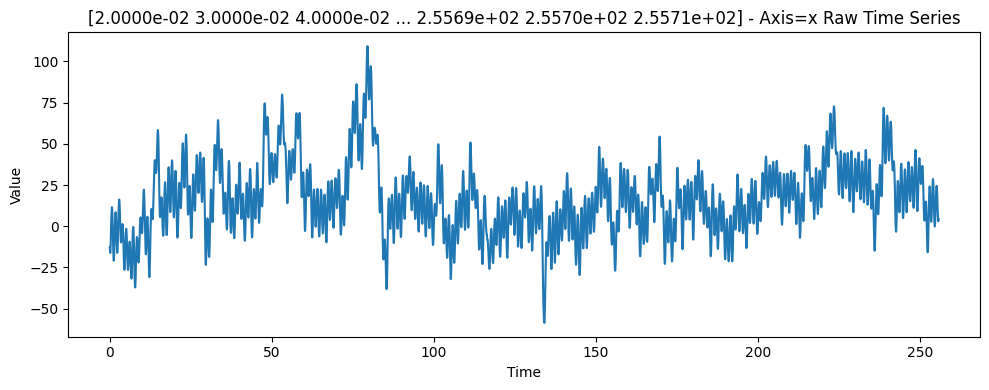

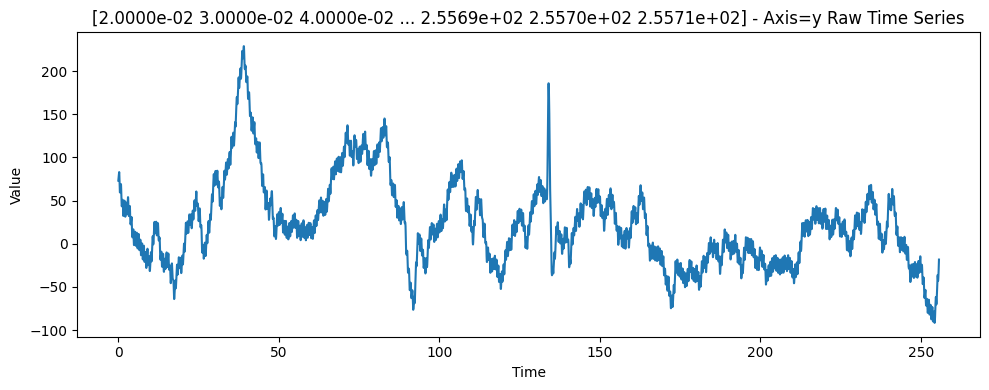

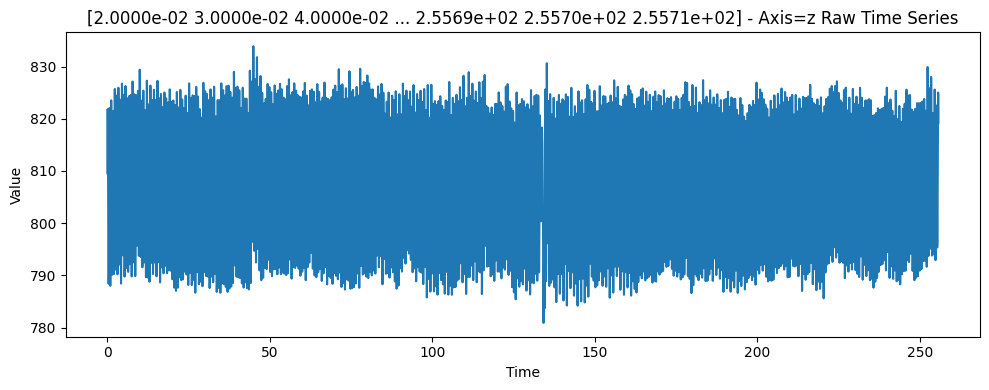

c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:195: RuntimeWarning: invalid value encountered in divide
  return (ts_bp - np.mean(ts_bp)) / np.std(ts_bp)


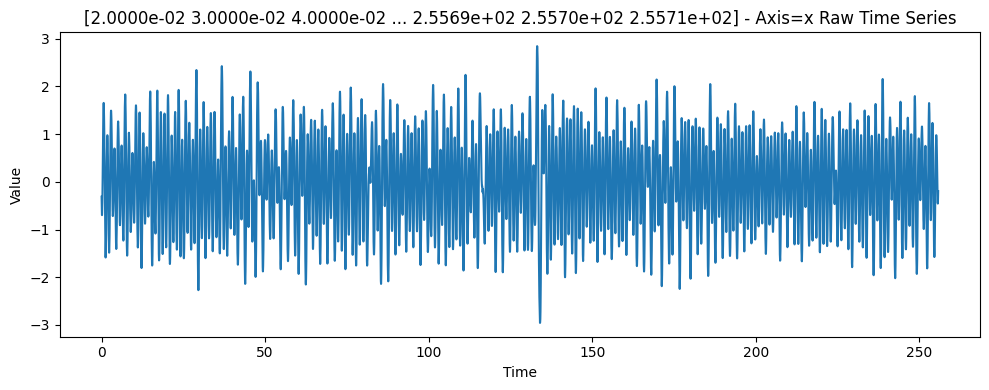

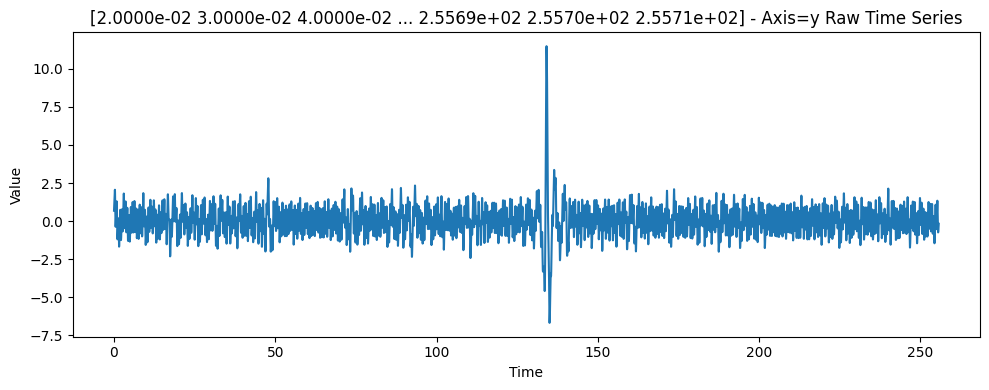

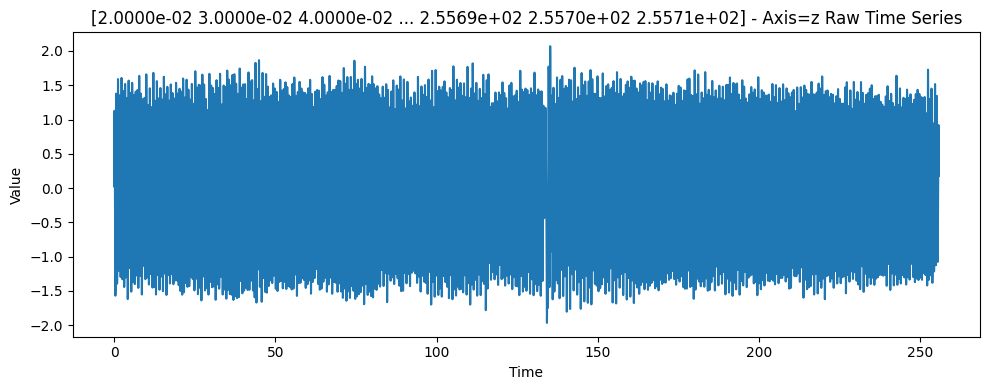

Baseline indices: [False False False ... False False False]
Perturbation indices: [False False False ... False False False]
Baseline stationarity:


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_15\stationarity_test\baseline_axisx_stationarity.txt


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_15\stationarity_test\baseline_axisy_stationarity.txt


...

Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_15\stationarity_test\recovery_axisx_stationarity.txt


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_15\stationarity_test\recovery_axisy_stationarity.txt


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_15\stationarity_test\recovery_axisz_stationarity.txt

--- Mean & Variance for markers.nc (COM) ---
Axis=x: Mean=-0.0000, Variance=1.0000
Axis=y: Mean=-0.0000, Variance=1.0000
Axis=z: Mean=-0.0000, Variance=1.0000
Saved rolling plot: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_15\stationarity_test\markers.nc_axisx_rolling.png
Saved rolling plot: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_15\stationarity_test\markers.nc_axisy_rolling.png
Saved rolling plot: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_15\stationarity_test\markers.nc_axisz_rolling.png


In [27]:

from pathlib import Path
import xarray as xr
cwd = Path.cwd()
print("Current working directory:", cwd.resolve())
data_path = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_15" / "Pre.3" / "markers.nc"
# events_path = cwd.parent / ".." / "data" / "CGA" / "04" / "PWS" / "4" / "PWS.4_events.csv"


ds = xr.open_dataset(data_path)
print("Dataset loaded. Variables:", list(ds.data_vars.keys()))

# Set parameters for your functions
data = ds['markers']
com=data.sel(channel='COM')  

dataset_name = "markers.nc"           
channel = "COM"                  
window_size = 100                
results_dir = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_15" / "stationarity_test"  
t = com.coords['time'].values
print("Time coordinates:", t)
plot_time_series(data, t, channel='COM')


# data = detrend_only(data, fs=100.0)
data  =process_data(data, fs=100.0,
                            low_lp=10.0,
                            low_bp=0.3,
                            high_bp=6.0,
                            do_zscore= True) 

plot_time_series(data, t, channel='COM')
perturbation_start = 120.00  # Start time of perturbation in seconds
idx_baseline   =  (t >= 25.0) & (t < perturbation_start)
perturbation_end = 150.00    # End time of perturbation in seconds
idx_perturb    = (t >= perturbation_start) & (t < perturbation_end)
idx_recovery   = t >= perturbation_end
print("Baseline indices:", idx_baseline)
print("Perturbation indices:", idx_perturb)
baseline   = data.sel(time=idx_baseline)
recovery   = data.sel(time=idx_recovery)

# 2) Test stationarity only on baseline & recovery:
print("Baseline stationarity:")
adf_kpss_test(baseline,  "baseline", channel, results_dir)
print("Recovery stationarity:")
adf_kpss_test(recovery,  "recovery", channel, results_dir)

mean_variance(data, dataset_name, channel=channel)
rolling_mean_variance(data, dataset_name, channel=channel, window_size=window_size, output_dir=results_dir)



# mean_variance(data, dataset_name, channel=channel)
# rolling_mean_variance(data, dataset_name, channel=channel, window_size=window_size, output_dir=results_dir)
# adf_kpss_test(data, dataset_name, channel=channel, output_dir=results_dir)

# PBT Young 16 - Stationarity ok

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Dataset loaded. Variables: ['markers']
Time coordinates: [0.0000e+00 1.0000e-02 2.0000e-02 ... 2.5369e+02 2.5370e+02 2.5371e+02]


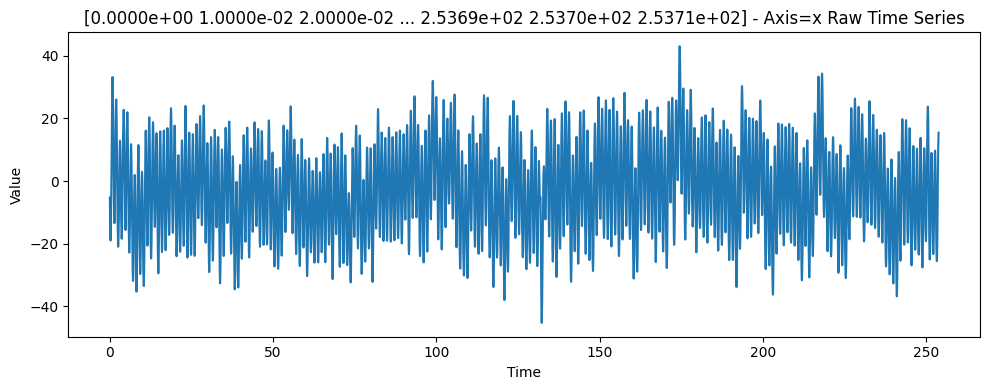

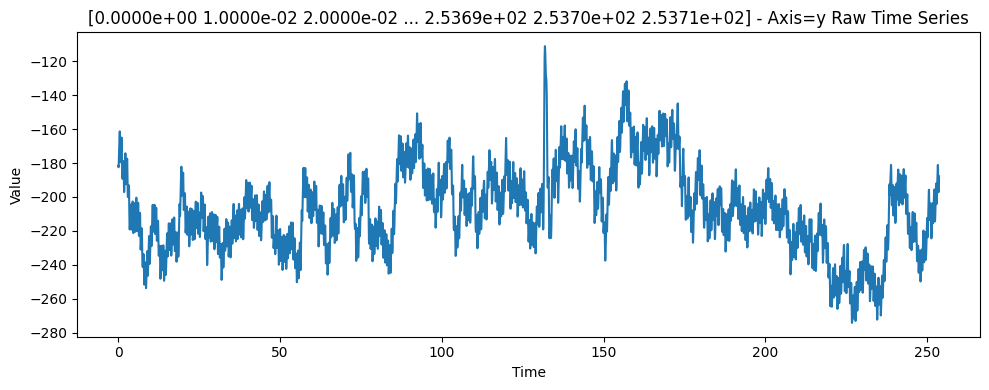

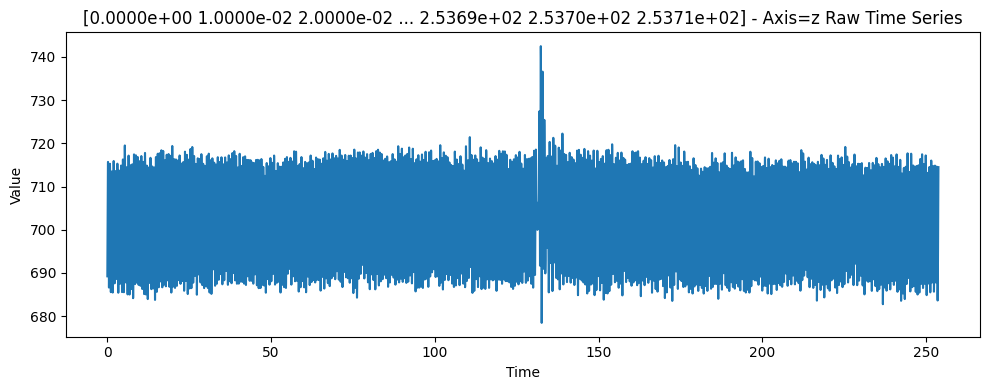

c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:195: RuntimeWarning: invalid value encountered in divide
  return (ts_bp - np.mean(ts_bp)) / np.std(ts_bp)


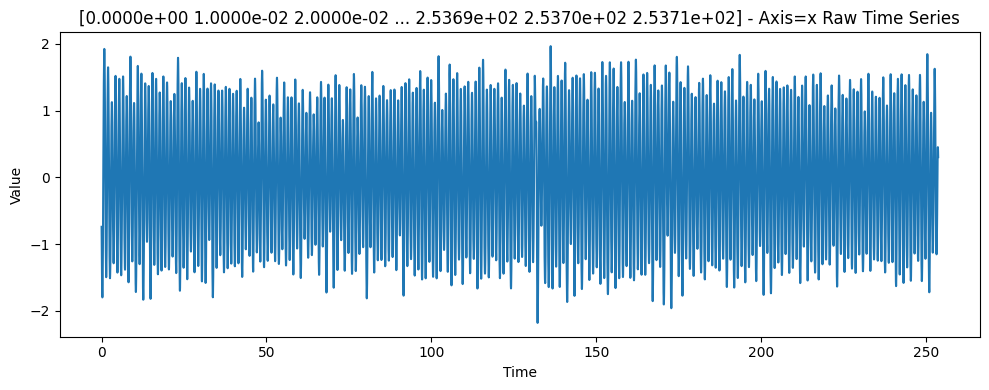

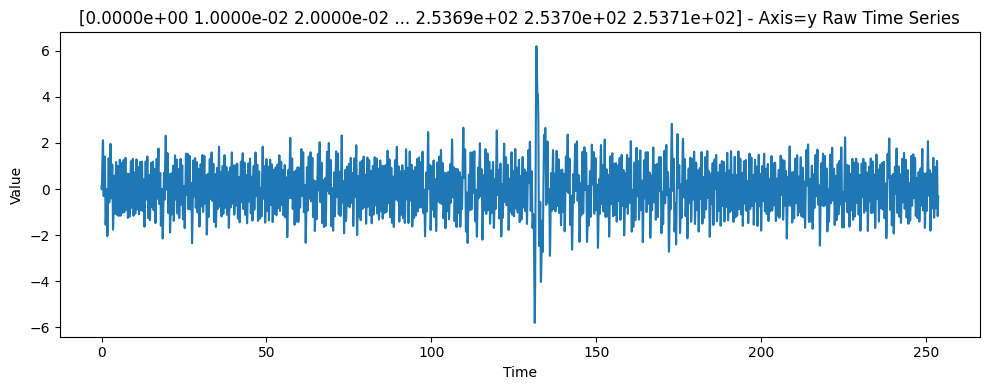

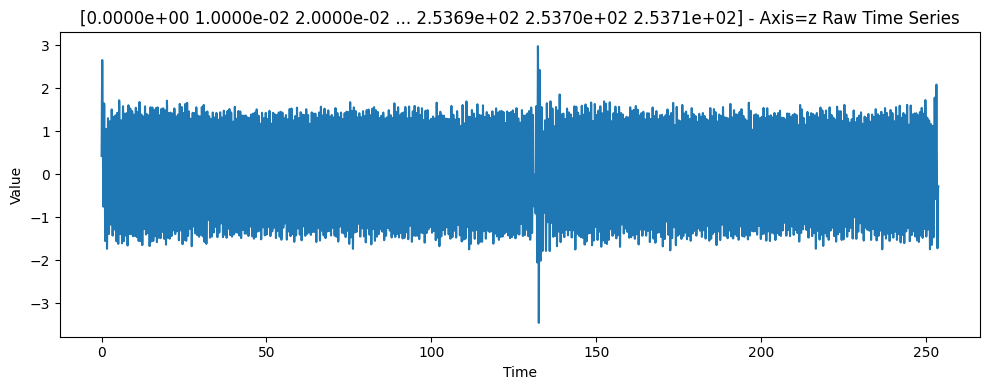

Baseline indices: [False False False ... False False False]
Perturbation indices: [False False False ... False False False]
Baseline stationarity:


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_16\stationarity_test\baseline_axisx_stationarity.txt


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_16\stationarity_test\baseline_axisy_stationarity.txt


...

Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_16\stationarity_test\recovery_axisx_stationarity.txt


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_16\stationarity_test\recovery_axisy_stationarity.txt


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_16\stationarity_test\recovery_axisz_stationarity.txt

--- Mean & Variance for markers.nc (COM) ---
Axis=x: Mean=0.0000, Variance=1.0000
Axis=y: Mean=-0.0000, Variance=1.0000
Axis=z: Mean=0.0000, Variance=1.0000
Saved rolling plot: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_16\stationarity_test\markers.nc_axisx_rolling.png
Saved rolling plot: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_16\stationarity_test\markers.nc_axisy_rolling.png
Saved rolling plot: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_16\stationarity_test\markers.nc_axisz_rolling.png


In [36]:

from pathlib import Path
import xarray as xr
cwd = Path.cwd()
print("Current working directory:", cwd.resolve())
data_path = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_16" / "Pre.3" / "markers.nc"
# events_path = cwd.parent / ".." / "data" / "CGA" / "04" / "PWS" / "4" / "PWS.4_events.csv"


ds = xr.open_dataset(data_path)
print("Dataset loaded. Variables:", list(ds.data_vars.keys()))

# Set parameters for your functions
data = ds['markers']
com=data.sel(channel='COM')  

dataset_name = "markers.nc"           
channel = "COM"                  
window_size = 100                
results_dir = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_16" / "stationarity_test"  
t = com.coords['time'].values
print("Time coordinates:", t)
plot_time_series(data, t, channel='COM')


# data = detrend_only(data, fs=100.0)
data  =process_data(data, fs=100.0,
                            low_lp=10.0,
                            low_bp=0.3,
                            high_bp=8.0,
                            do_zscore= True) 

plot_time_series(data, t, channel='COM')
perturbation_start = 120.00  # Start time of perturbation in seconds
idx_baseline   =  (t >= 25.0) & (t < perturbation_start)
perturbation_end = 150.00    # End time of perturbation in seconds
idx_perturb    = (t >= perturbation_start) & (t < perturbation_end)
idx_recovery   = (t >= perturbation_end) & (t < 230.0)
print("Baseline indices:", idx_baseline)
print("Perturbation indices:", idx_perturb)
baseline   = data.sel(time=idx_baseline)
recovery   = data.sel(time=idx_recovery)

# 2) Test stationarity only on baseline & recovery:
print("Baseline stationarity:")
adf_kpss_test(baseline,  "baseline", channel, results_dir)
print("Recovery stationarity:")
adf_kpss_test(recovery,  "recovery", channel, results_dir)

mean_variance(data, dataset_name, channel=channel)
rolling_mean_variance(data, dataset_name, channel=channel, window_size=window_size, output_dir=results_dir)



# mean_variance(data, dataset_name, channel=channel)
# rolling_mean_variance(data, dataset_name, channel=channel, window_size=window_size, output_dir=results_dir)
# adf_kpss_test(data, dataset_name, channel=channel, output_dir=results_dir)

# PBT Young 17 - Stationarity ok

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Dataset loaded. Variables: ['markers']
Time coordinates: [ 10.3   10.31  10.32 ... 250.5  250.51 250.52]


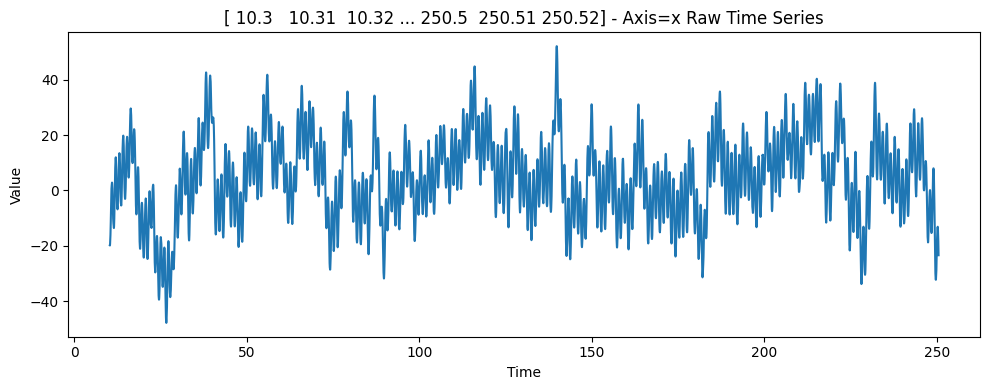

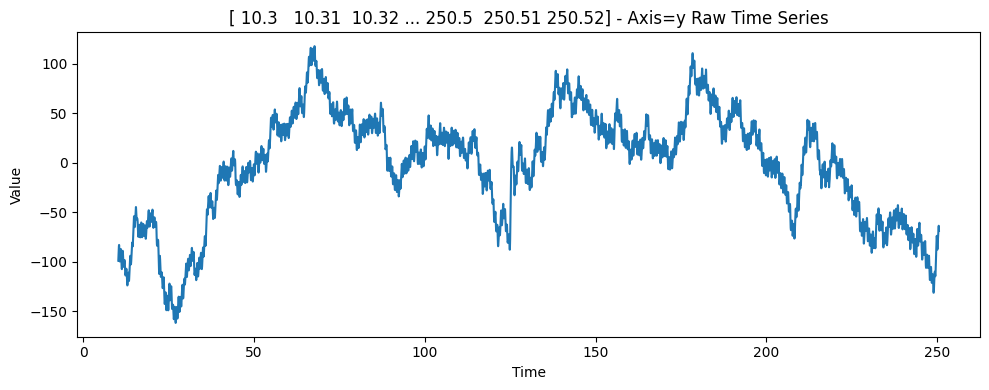

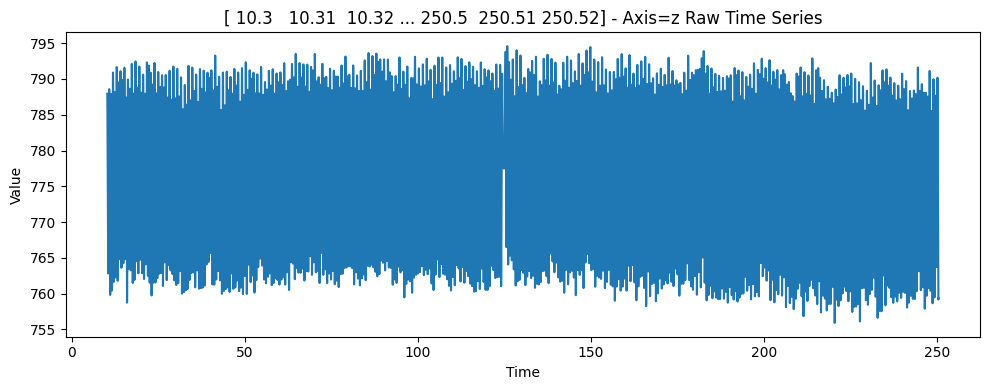

c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:195: RuntimeWarning: invalid value encountered in divide
  return (ts_bp - np.mean(ts_bp)) / np.std(ts_bp)


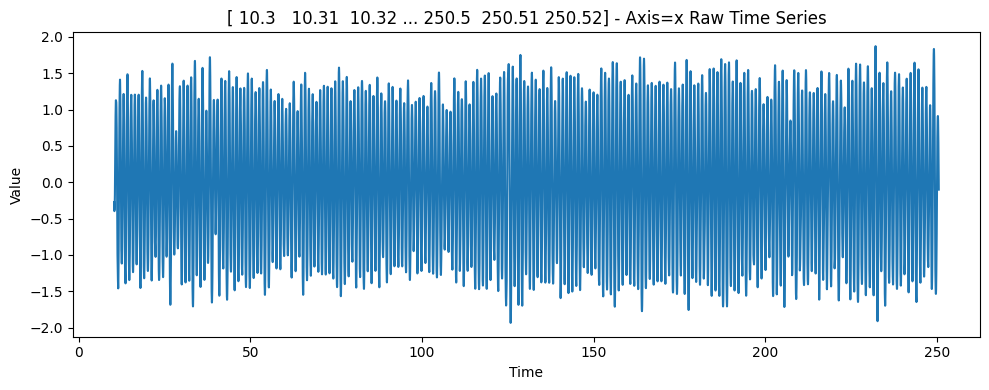

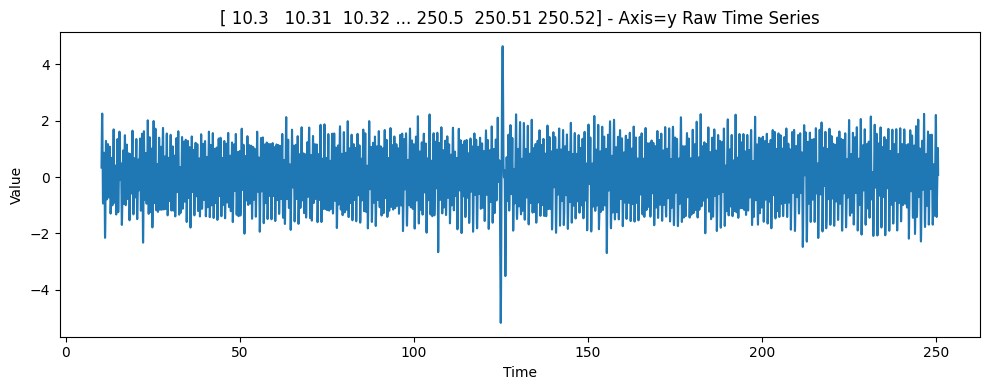

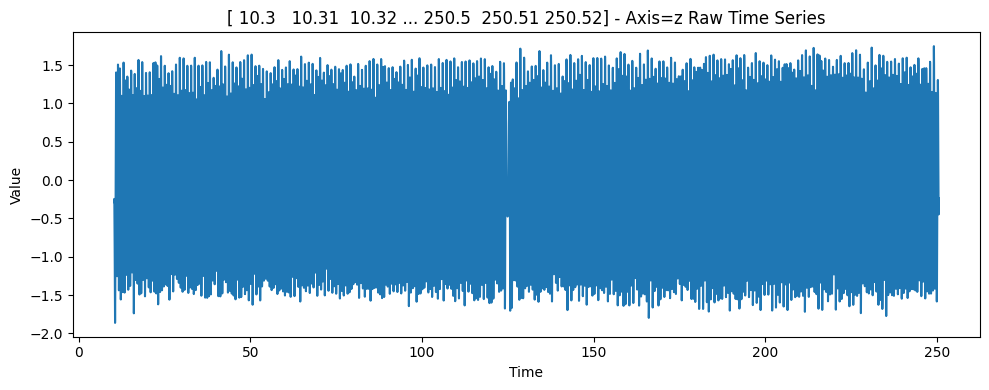

Baseline indices: [False False False ... False False False]
Perturbation indices: [False False False ... False False False]
Baseline stationarity:


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_17\stationarity_test\baseline_axisx_stationarity.txt


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_17\stationarity_test\baseline_axisy_stationarity.txt


...

Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_17\stationarity_test\recovery_axisx_stationarity.txt


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_17\stationarity_test\recovery_axisy_stationarity.txt


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_17\stationarity_test\recovery_axisz_stationarity.txt

--- Mean & Variance for markers.nc (COM) ---
Axis=x: Mean=0.0000, Variance=1.0000
Axis=y: Mean=-0.0000, Variance=1.0000
Axis=z: Mean=0.0000, Variance=1.0000
Saved rolling plot: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_17\stationarity_test\markers.nc_axisx_rolling.png
Saved rolling plot: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_17\stationarity_test\markers.nc_axisy_rolling.png
Saved rolling plot: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_17\stationarity_test\markers.nc_axisz_rolling.png


In [44]:

from pathlib import Path
import xarray as xr
cwd = Path.cwd()
print("Current working directory:", cwd.resolve())
data_path = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_17" / "Pre.3" / "markers.nc"
# events_path = cwd.parent / ".." / "data" / "CGA" / "04" / "PWS" / "4" / "PWS.4_events.csv"


ds = xr.open_dataset(data_path)
print("Dataset loaded. Variables:", list(ds.data_vars.keys()))

# Set parameters for your functions
data = ds['markers']
com=data.sel(channel='COM')  

dataset_name = "markers.nc"           
channel = "COM"                  
window_size = 100                
results_dir = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_17" / "stationarity_test"  
t = com.coords['time'].values
print("Time coordinates:", t)
plot_time_series(data, t, channel='COM')


# data = detrend_only(data, fs=100.0)
data  =process_data(data, fs=100.0,
                            low_lp=15.0,
                            low_bp=0.5,
                            high_bp=8.0,
                            do_zscore= True) 

plot_time_series(data, t, channel='COM')
perturbation_start = 110.00  # Start time of perturbation in seconds
idx_baseline   =  (t >= 25.0) & (t < perturbation_start)
perturbation_end = 150.00    # End time of perturbation in seconds
idx_perturb    = (t >= perturbation_start) & (t < perturbation_end)
idx_recovery   = (t >= perturbation_end) & (t < 230.0)
print("Baseline indices:", idx_baseline)
print("Perturbation indices:", idx_perturb)
baseline   = data.sel(time=idx_baseline)
recovery   = data.sel(time=idx_recovery)

# 2) Test stationarity only on baseline & recovery:
print("Baseline stationarity:")
adf_kpss_test(baseline,  "baseline", channel, results_dir)
print("Recovery stationarity:")
adf_kpss_test(recovery,  "recovery", channel, results_dir)

mean_variance(data, dataset_name, channel=channel)
rolling_mean_variance(data, dataset_name, channel=channel, window_size=window_size, output_dir=results_dir)



# mean_variance(data, dataset_name, channel=channel)
# rolling_mean_variance(data, dataset_name, channel=channel, window_size=window_size, output_dir=results_dir)
# adf_kpss_test(data, dataset_name, channel=channel, output_dir=results_dir)

# Patient 18 - Stationarity ok 

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Dataset loaded. Variables: ['markers']
Time coordinates: [0.0000e+00 1.0000e-02 2.0000e-02 ... 2.4666e+02 2.4667e+02 2.4668e+02]


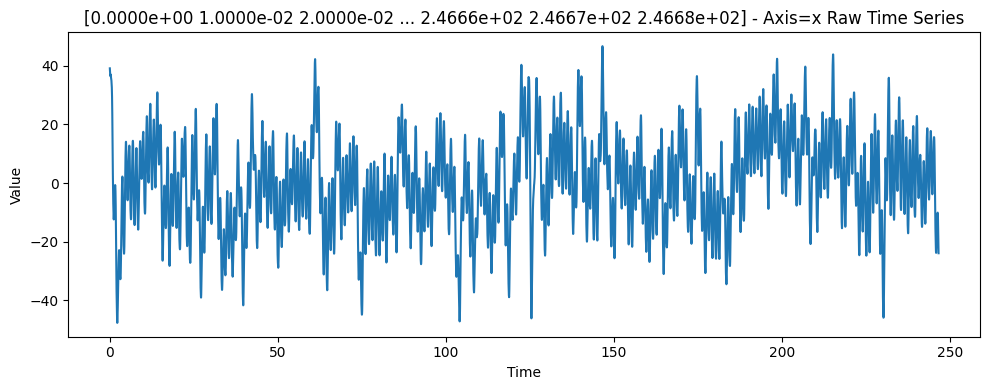

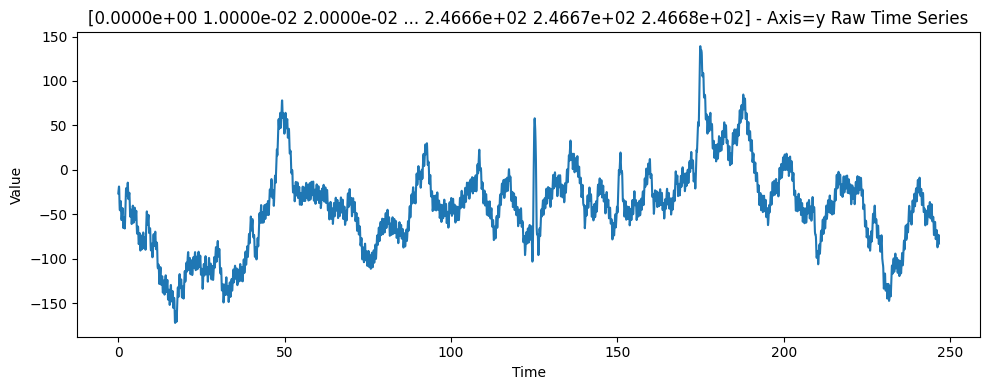

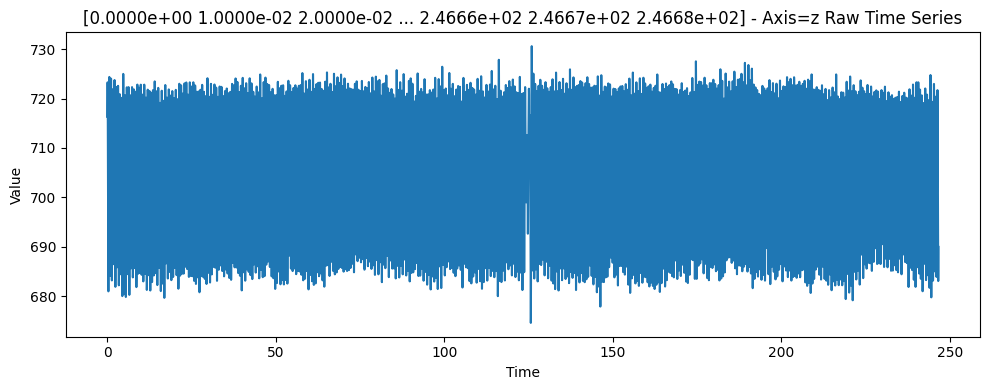

c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:195: RuntimeWarning: invalid value encountered in divide
  return (ts_bp - np.mean(ts_bp)) / np.std(ts_bp)


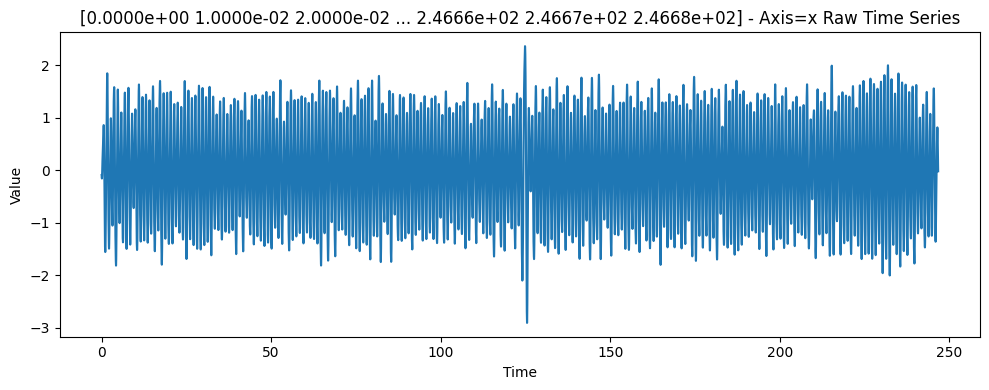

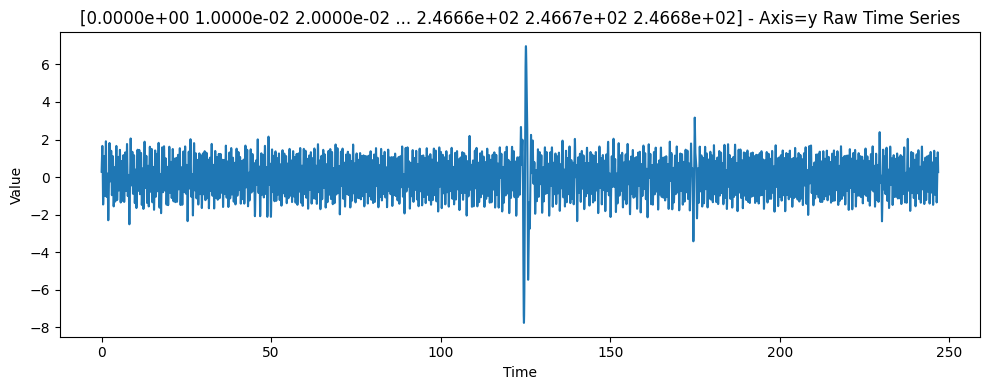

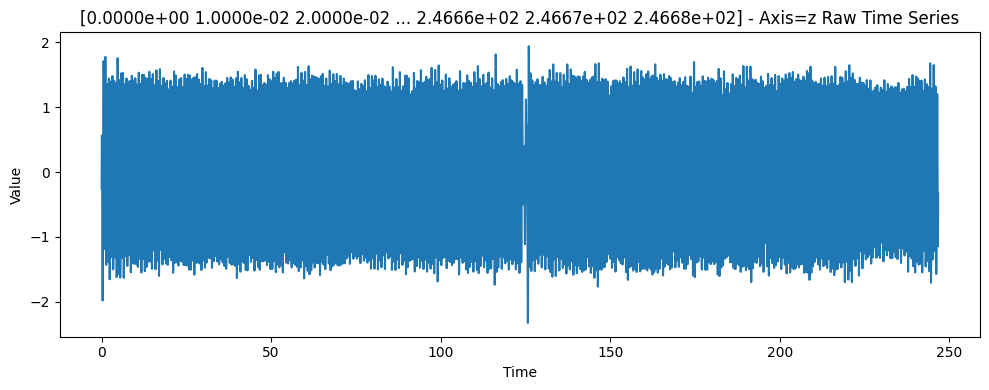

Baseline indices: [False False False ... False False False]
Perturbation indices: [False False False ... False False False]
Baseline stationarity:


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_18\stationarity_test\baseline_axisx_stationarity.txt


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_18\stationarity_test\baseline_axisy_stationarity.txt


...

Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_18\stationarity_test\recovery_axisx_stationarity.txt


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_18\stationarity_test\recovery_axisy_stationarity.txt


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_18\stationarity_test\recovery_axisz_stationarity.txt

--- Mean & Variance for markers.nc (COM) ---
Axis=x: Mean=0.0000, Variance=1.0000
Axis=y: Mean=-0.0000, Variance=1.0000
Axis=z: Mean=-0.0000, Variance=1.0000
Saved rolling plot: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_18\stationarity_test\markers.nc_axisx_rolling.png
Saved rolling plot: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_18\stationarity_test\markers.nc_axisy_rolling.png
Saved rolling plot: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_18\stationarity_test\markers.nc_axisz_rolling.png


In [54]:

from pathlib import Path
import xarray as xr
cwd = Path.cwd()
print("Current working directory:", cwd.resolve())
data_path = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_18" / "Pre.3" / "markers.nc"
# events_path = cwd.parent / ".." / "data" / "CGA" / "04" / "PWS" / "4" / "PWS.4_events.csv"


ds = xr.open_dataset(data_path)
print("Dataset loaded. Variables:", list(ds.data_vars.keys()))

# Set parameters for your functions
data = ds['markers']
com=data.sel(channel='COM')  

dataset_name = "markers.nc"           
channel = "COM"                  
window_size = 100                
results_dir = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_18" / "stationarity_test"  
t = com.coords['time'].values
print("Time coordinates:", t)
plot_time_series(data, t, channel='COM')


# data = detrend_only(data, fs=100.0)
data  =process_data(data, fs=100.0,
                            low_lp=5.0,
                            low_bp=0.5,
                            high_bp=10.0,
                            do_zscore= True) 

plot_time_series(data, t, channel='COM')
perturbation_start = 110.00  # Start time of perturbation in seconds
idx_baseline   =  (t >= 25.0) & (t < perturbation_start)
perturbation_end = 150.00    # End time of perturbation in seconds
idx_perturb    = (t >= perturbation_start) & (t < perturbation_end)
idx_recovery   = (t >= perturbation_end) & (t < 230.0)
print("Baseline indices:", idx_baseline)
print("Perturbation indices:", idx_perturb)
baseline   = data.sel(time=idx_baseline)
recovery   = data.sel(time=idx_recovery)

# 2) Test stationarity only on baseline & recovery:
print("Baseline stationarity:")
adf_kpss_test(baseline,  "baseline", channel, results_dir)
print("Recovery stationarity:")
adf_kpss_test(recovery,  "recovery", channel, results_dir)

mean_variance(data, dataset_name, channel=channel)
rolling_mean_variance(data, dataset_name, channel=channel, window_size=window_size, output_dir=results_dir)



# mean_variance(data, dataset_name, channel=channel)
# rolling_mean_variance(data, dataset_name, channel=channel, window_size=window_size, output_dir=results_dir)
# adf_kpss_test(data, dataset_name, channel=channel, output_dir=results_dir)

# Patient 19 - Stationarity ok

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Dataset loaded. Variables: ['markers']
Time coordinates: [1.0000e-02 2.0000e-02 3.0000e-02 ... 2.5044e+02 2.5045e+02 2.5046e+02]


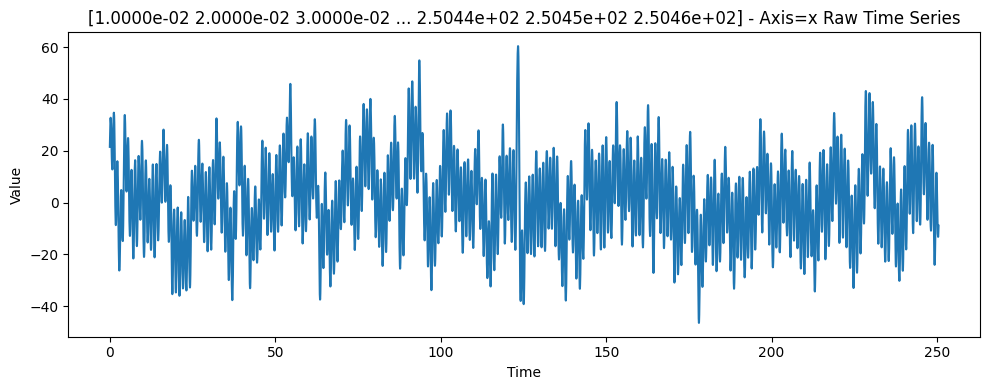

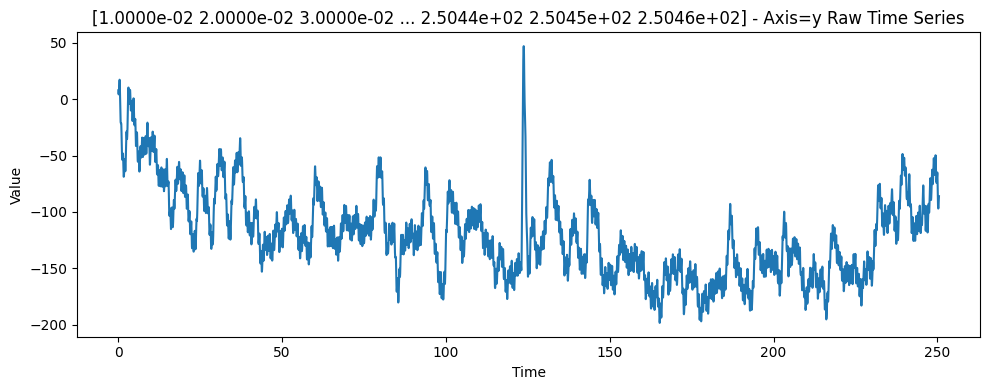

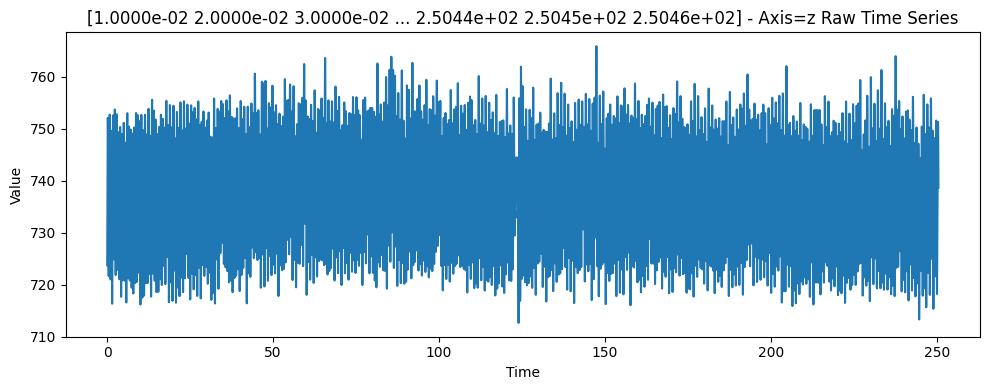

c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:195: RuntimeWarning: invalid value encountered in divide
  return (ts_bp - np.mean(ts_bp)) / np.std(ts_bp)


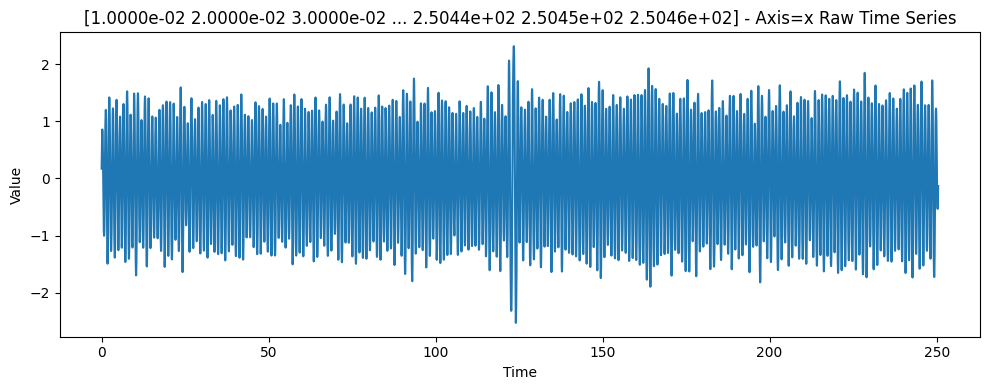

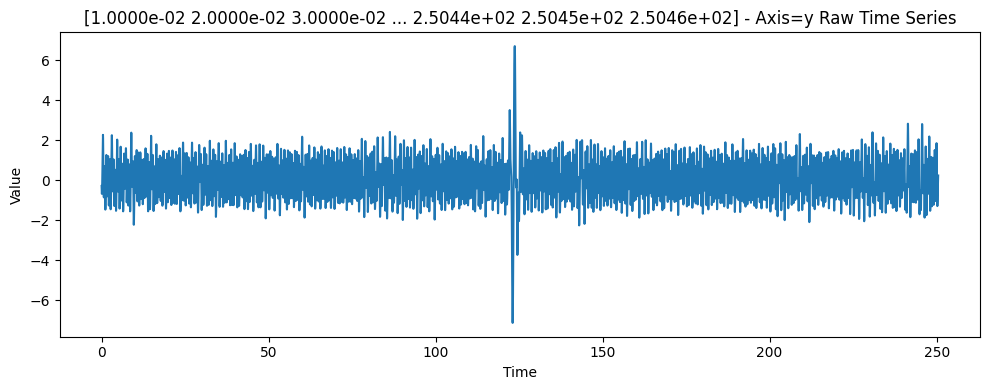

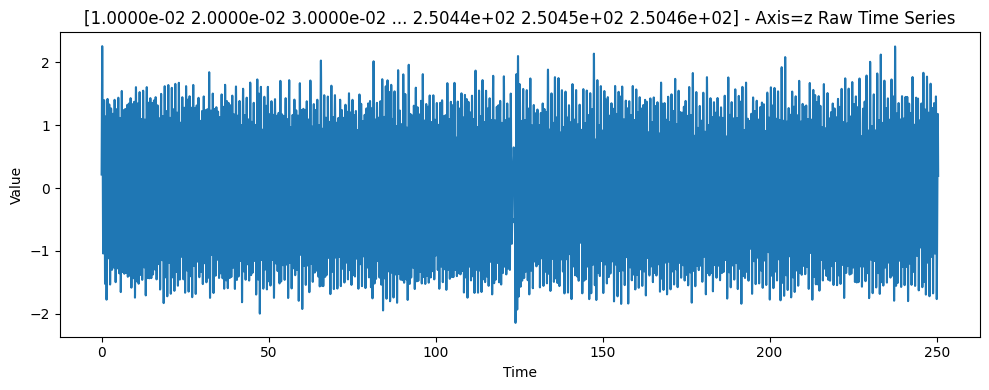

Baseline indices: [False False False ... False False False]
Perturbation indices: [False False False ... False False False]
Baseline stationarity:


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_19\stationarity_test\baseline_axisx_stationarity.txt


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_19\stationarity_test\baseline_axisy_stationarity.txt


...

Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_19\stationarity_test\recovery_axisx_stationarity.txt


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_19\stationarity_test\recovery_axisy_stationarity.txt


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_19\stationarity_test\recovery_axisz_stationarity.txt

--- Mean & Variance for markers.nc (COM) ---
Axis=x: Mean=-0.0000, Variance=1.0000
Axis=y: Mean=0.0000, Variance=1.0000
Axis=z: Mean=0.0000, Variance=1.0000
Saved rolling plot: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_19\stationarity_test\markers.nc_axisx_rolling.png
Saved rolling plot: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_19\stationarity_test\markers.nc_axisy_rolling.png
Saved rolling plot: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_19\stationarity_test\markers.nc_axisz_rolling.png


In [56]:

from pathlib import Path
import xarray as xr
cwd = Path.cwd()
print("Current working directory:", cwd.resolve())
data_path = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_19" / "Pre.3" / "markers.nc"
# events_path = cwd.parent / ".." / "data" / "CGA" / "04" / "PWS" / "4" / "PWS.4_events.csv"


ds = xr.open_dataset(data_path)
print("Dataset loaded. Variables:", list(ds.data_vars.keys()))

# Set parameters for your functions
data = ds['markers']
com=data.sel(channel='COM')  

dataset_name = "markers.nc"           
channel = "COM"                  
window_size = 100                
results_dir = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_19" / "stationarity_test"  
t = com.coords['time'].values
print("Time coordinates:", t)
plot_time_series(data, t, channel='COM')


# data = detrend_only(data, fs=100.0)
data  =process_data(data, fs=100.0,
                            low_lp=10.0,
                            low_bp=0.5,
                            high_bp=5.0,
                            do_zscore= True) 

plot_time_series(data, t, channel='COM')
perturbation_start = 110.00  # Start time of perturbation in seconds
idx_baseline   =  (t >= 25.0) & (t < perturbation_start)
perturbation_end = 150.00    # End time of perturbation in seconds
idx_perturb    = (t >= perturbation_start) & (t < perturbation_end)
idx_recovery   = (t >= perturbation_end) & (t < 230.0)
print("Baseline indices:", idx_baseline)
print("Perturbation indices:", idx_perturb)
baseline   = data.sel(time=idx_baseline)
recovery   = data.sel(time=idx_recovery)

# 2) Test stationarity only on baseline & recovery:
print("Baseline stationarity:")
adf_kpss_test(baseline,  "baseline", channel, results_dir)
print("Recovery stationarity:")
adf_kpss_test(recovery,  "recovery", channel, results_dir)

mean_variance(data, dataset_name, channel=channel)
rolling_mean_variance(data, dataset_name, channel=channel, window_size=window_size, output_dir=results_dir)



# mean_variance(data, dataset_name, channel=channel)
# rolling_mean_variance(data, dataset_name, channel=channel, window_size=window_size, output_dir=results_dir)
# adf_kpss_test(data, dataset_name, channel=channel, output_dir=results_dir)

# Patient 20 - Stationarity ok

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Dataset loaded. Variables: ['markers']
Time coordinates: [0.0000e+00 1.0000e-02 2.0000e-02 ... 2.4431e+02 2.4432e+02 2.4433e+02]


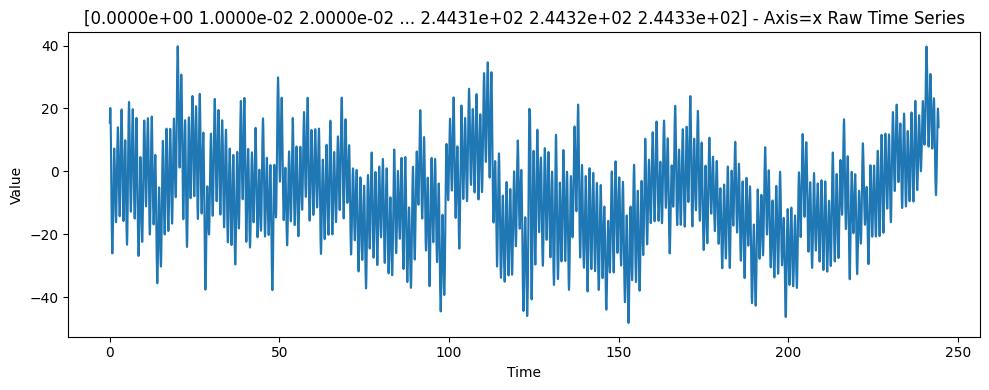

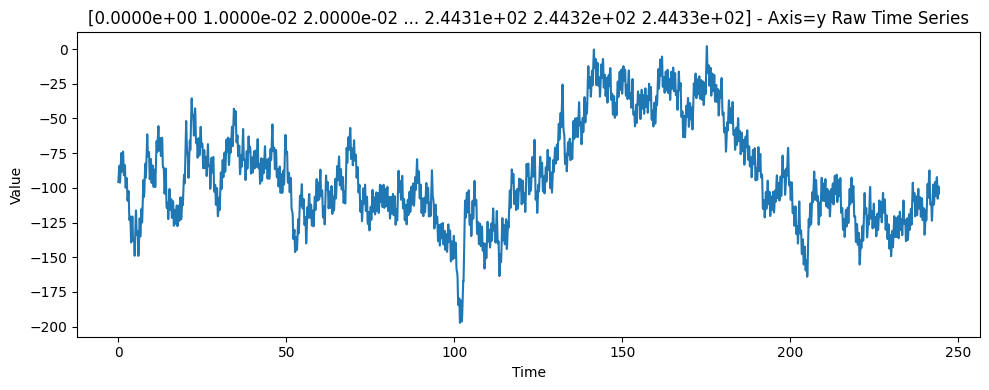

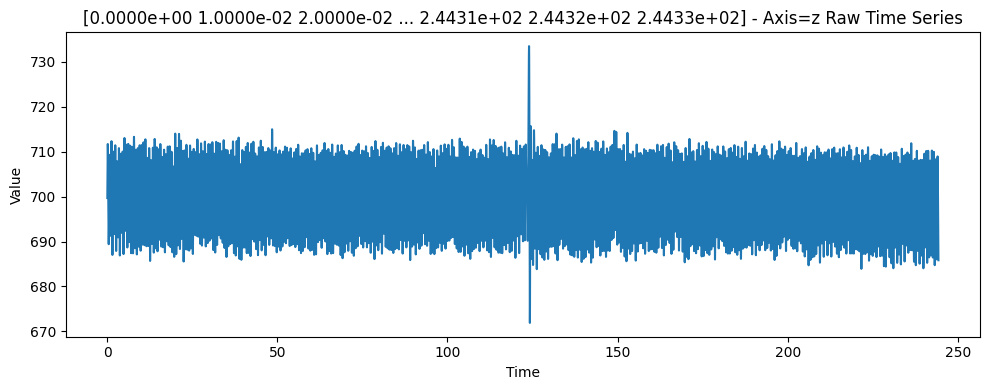

c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:195: RuntimeWarning: invalid value encountered in divide
  return (ts_bp - np.mean(ts_bp)) / np.std(ts_bp)


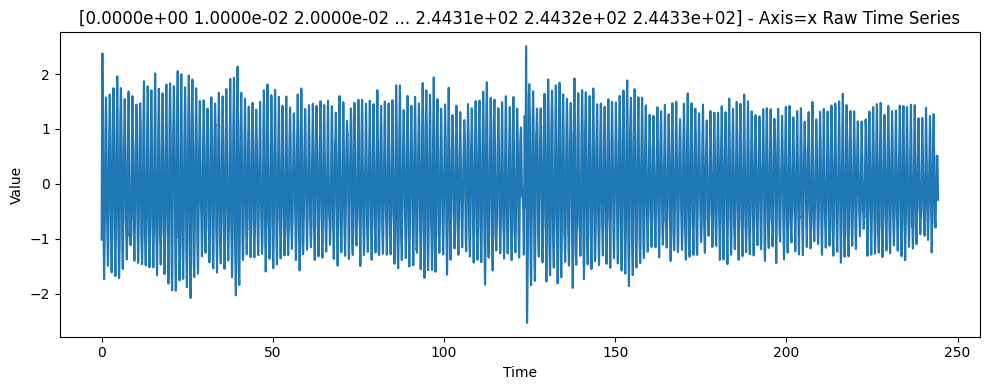

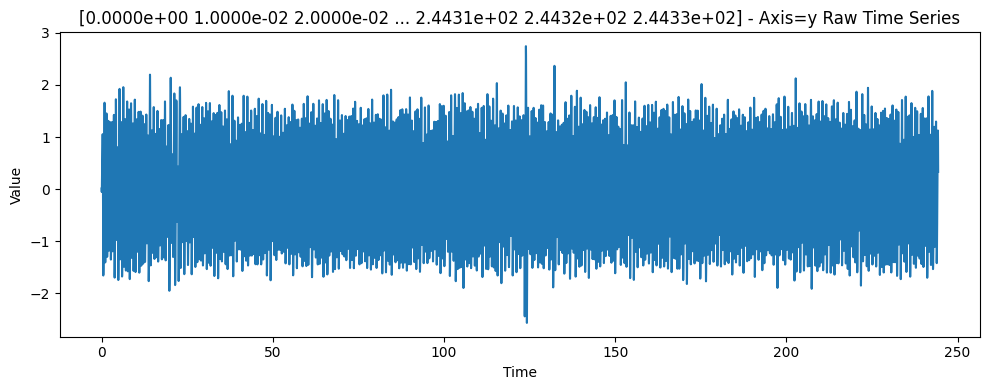

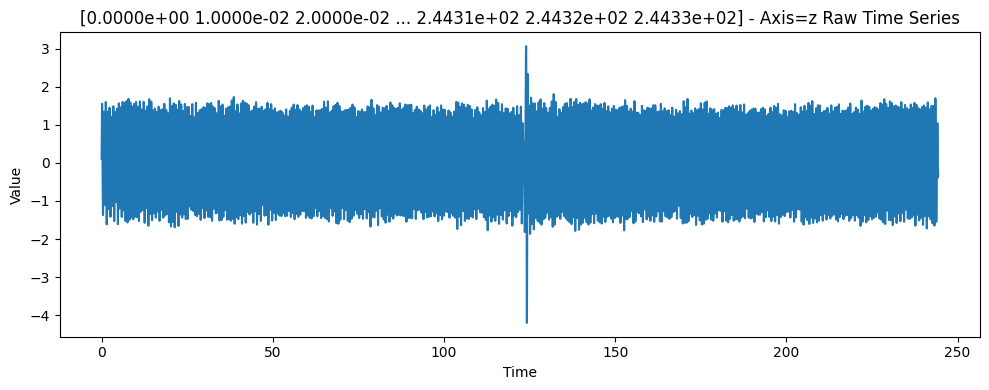

Baseline indices: [False False False ... False False False]
Perturbation indices: [False False False ... False False False]
Baseline stationarity:


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_20\stationarity_test\baseline_axisx_stationarity.txt


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_20\stationarity_test\baseline_axisy_stationarity.txt


...

Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_20\stationarity_test\recovery_axisx_stationarity.txt


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_20\stationarity_test\recovery_axisy_stationarity.txt


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_20\stationarity_test\recovery_axisz_stationarity.txt

--- Mean & Variance for markers.nc (COM) ---
Axis=x: Mean=0.0000, Variance=1.0000
Axis=y: Mean=-0.0000, Variance=1.0000
Axis=z: Mean=0.0000, Variance=1.0000
Saved rolling plot: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_20\stationarity_test\markers.nc_axisx_rolling.png
Saved rolling plot: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_20\stationarity_test\markers.nc_axisy_rolling.png
Saved rolling plot: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\PBT\Young\Cereneo_SR_20\stationarity_test\markers.nc_axisz_rolling.png


In [61]:

from pathlib import Path
import xarray as xr
cwd = Path.cwd()
print("Current working directory:", cwd.resolve())
data_path = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_20" / "Pre.3" / "markers.nc"
# events_path = cwd.parent / ".." / "data" / "CGA" / "04" / "PWS" / "4" / "PWS.4_events.csv"


ds = xr.open_dataset(data_path)
print("Dataset loaded. Variables:", list(ds.data_vars.keys()))

# Set parameters for your functions
data = ds['markers']
com=data.sel(channel='COM')  

dataset_name = "markers.nc"           
channel = "COM"                  
window_size = 100                
results_dir = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_20" / "stationarity_test"  
t = com.coords['time'].values
print("Time coordinates:", t)
plot_time_series(data, t, channel='COM')


# data = detrend_only(data, fs=100.0)
data  =process_data(data, fs=100.0,
                            low_lp=10.0,
                            low_bp=1.0,
                            high_bp=8.0,
                            do_zscore= True) 

plot_time_series(data, t, channel='COM')
perturbation_start = 110.00  # Start time of perturbation in seconds
idx_baseline   =  (t >= 25.0) & (t < perturbation_start)
perturbation_end = 150.00    # End time of perturbation in seconds
idx_perturb    = (t >= perturbation_start) & (t < perturbation_end)
idx_recovery   = (t >= perturbation_end) & (t < 230.0)
print("Baseline indices:", idx_baseline)
print("Perturbation indices:", idx_perturb)
baseline   = data.sel(time=idx_baseline)
recovery   = data.sel(time=idx_recovery)

# 2) Test stationarity only on baseline & recovery:
print("Baseline stationarity:")
adf_kpss_test(baseline,  "baseline", channel, results_dir)
print("Recovery stationarity:")
adf_kpss_test(recovery,  "recovery", channel, results_dir)

mean_variance(data, dataset_name, channel=channel)
rolling_mean_variance(data, dataset_name, channel=channel, window_size=window_size, output_dir=results_dir)



# mean_variance(data, dataset_name, channel=channel)
# rolling_mean_variance(data, dataset_name, channel=channel, window_size=window_size, output_dir=results_dir)
# adf_kpss_test(data, dataset_name, channel=channel, output_dir=results_dir)

# CGA Patient 4

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Dataset loaded. Variables: ['markers']
Time coordinates: [0.000e+00 1.000e-02 2.000e-02 ... 6.983e+01 6.984e+01 6.985e+01]


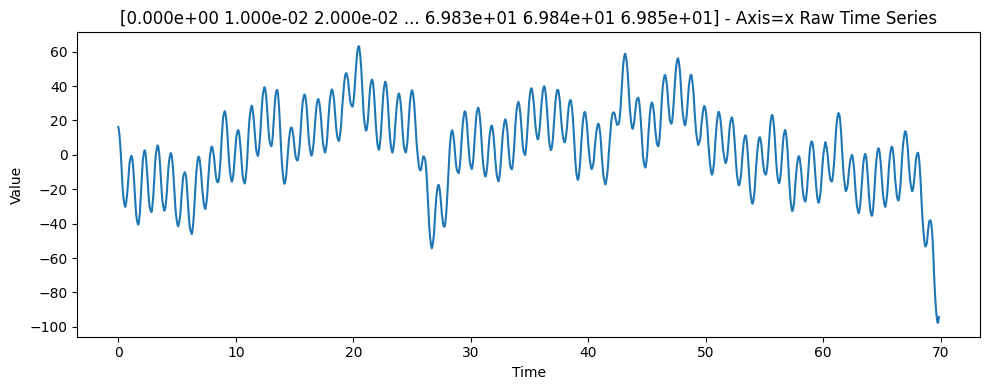

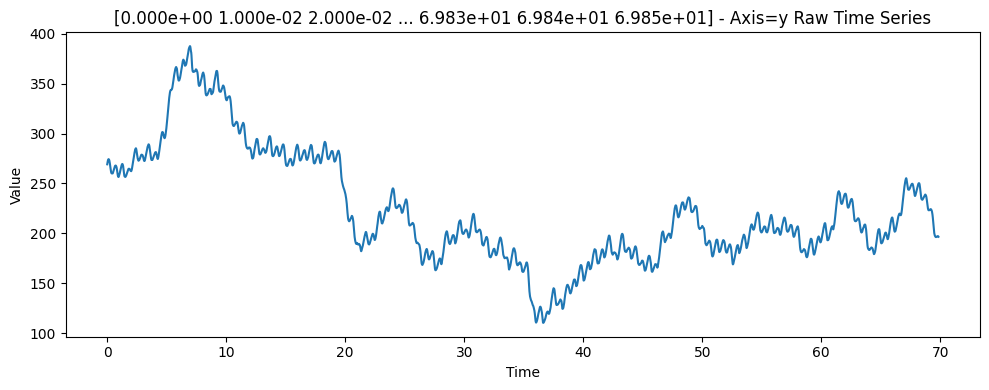

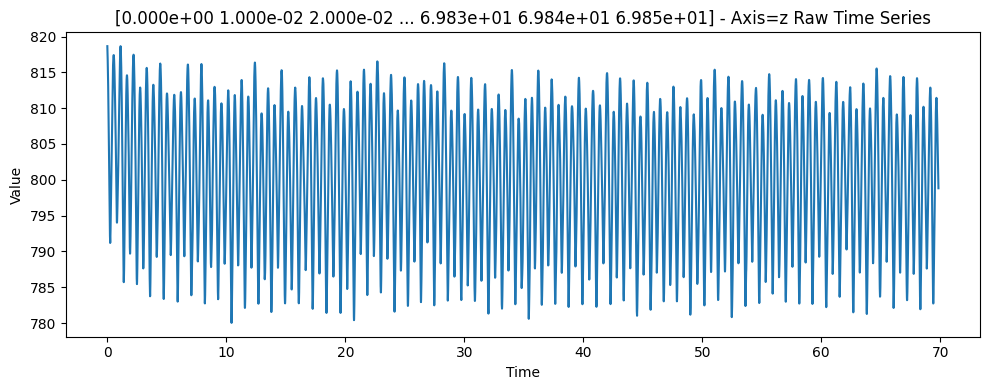

c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:211: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  try:
c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:195: RuntimeWarning: invalid value encountered in divide
  


Preprocessing failed for axis=x, channel=LGroundReactionForce: array must not contain infs or NaNs
Preprocessing failed for axis=x, channel=LNormalisedGRF: array must not contain infs or NaNs
Preprocessing failed for axis=x, channel=RGroundReactionForce: array must not contain infs or NaNs
Preprocessing failed for axis=x, channel=RNormalisedGRF: array must not contain infs or NaNs
Preprocessing failed for axis=x, channel=LAnkleForce: array must not contain infs or NaNs
Preprocessing failed for axis=x, channel=RAnkleForce: array must not contain infs or NaNs
Preprocessing failed for axis=x, channel=RKneeForce: array must not contain infs or NaNs
Preprocessing failed for axis=x, channel=LKneeForce: array must not contain infs or NaNs
Preprocessing failed for axis=x, channel=RHipForce: array must not contain infs or NaNs
Preprocessing failed for axis=x, channel=LHipForce: array must not contain infs or NaNs
Preprocessing failed for axis=x, channel=LWaistForce: array must not contain infs 

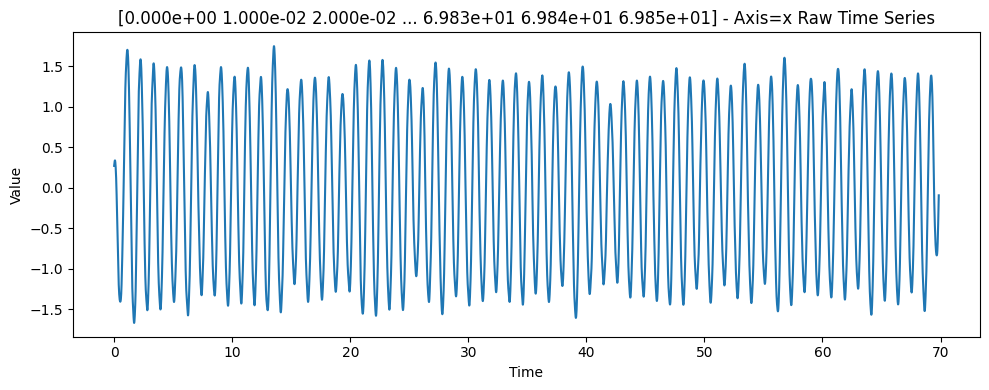

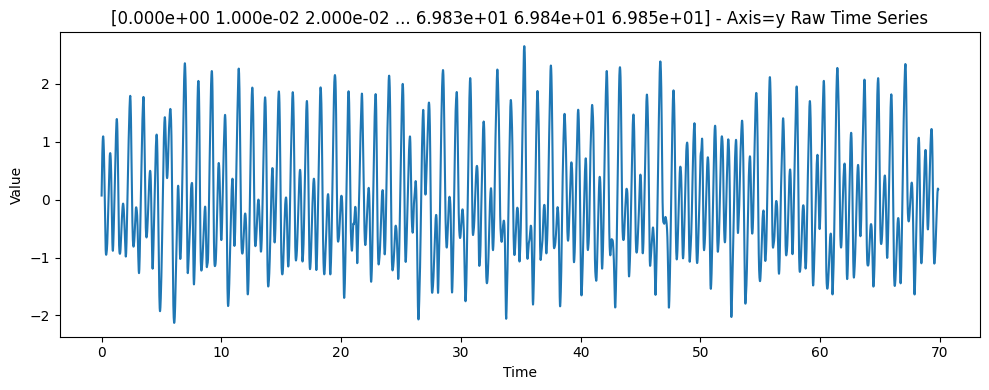

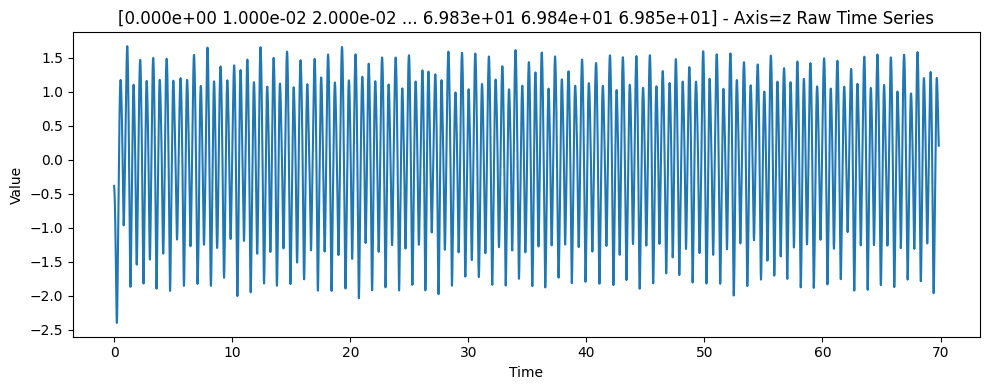


--- Mean & Variance for markers.nc (COM) ---
Axis=x: Mean=-0.0000, Variance=1.0000
Axis=y: Mean=0.0000, Variance=1.0000
Axis=z: Mean=0.0000, Variance=1.0000
Saved rolling plot: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\CGA\04\PWS\stationarity_test\markers.nc_axisx_rolling.png
Saved rolling plot: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\CGA\04\PWS\stationarity_test\markers.nc_axisy_rolling.png
Saved rolling plot: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\CGA\04\PWS\stationarity_test\markers.nc_axisz_rolling.png


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\CGA\04\PWS\stationarity_test\markers.nc_axisx_stationarity.txt


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\CGA\04\PWS\stationarity_test\markers.nc_axisy_stationarity.txt
Saved stationarity results: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\..\data\CGA\04\PWS\stationarity_test\markers.nc_axisz_stationarity.txt


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\stationarity_tests.py:93: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, nlags='auto')


In [64]:

from pathlib import Path
import xarray as xr
cwd = Path.cwd()
print("Current working directory:", cwd.resolve())
data_path = cwd.parent / ".." /"data"/"CGA" /"04"/"PWS"/"4"/"markers.nc"
# events_path = cwd.parent / ".." / "data" / "CGA" / "04" / "PWS" / "4" / "PWS.4_events.csv"


ds = xr.open_dataset(data_path)
print("Dataset loaded. Variables:", list(ds.data_vars.keys()))

# Set parameters for your functions
data = ds['markers']
com=data.sel(channel='COM')  

dataset_name = "markers.nc"           
channel = "COM"                  
window_size = 100                
results_dir = cwd.parent / ".." /"data"/"CGA" /"04"/"PWS"/"stationarity_test"
t = com.coords['time'].values
print("Time coordinates:", t)
plot_time_series(data, t, channel='COM')


# data = detrend_only(data, fs=100.0)
data  =process_data(data, fs=100.0,
                            low_lp=10.0,
                            low_bp=0.5,
                            high_bp=8.0,
                            do_zscore= True) 

plot_time_series(data, t, channel='COM')
# perturbation_start = 110.00  # Start time of perturbation in seconds
# idx_baseline   =  (t >= 25.0) & (t < perturbation_start)
# perturbation_end = 150.00    # End time of perturbation in seconds
# idx_perturb    = (t >= perturbation_start) & (t < perturbation_end)
# idx_recovery   = (t >= perturbation_end) & (t < 230.0)
# print("Baseline indices:", idx_baseline)
# print("Perturbation indices:", idx_perturb)
# baseline   = data.sel(time=idx_baseline)
# recovery   = data.sel(time=idx_recovery)

# # 2) Test stationarity only on baseline & recovery:
# print("Baseline stationarity:")
# adf_kpss_test(baseline,  "baseline", channel, results_dir)
# print("Recovery stationarity:")
# adf_kpss_test(recovery,  "recovery", channel, results_dir)

# mean_variance(data, dataset_name, channel=channel)
# rolling_mean_variance(data, dataset_name, channel=channel, window_size=window_size, output_dir=results_dir)



mean_variance(data, dataset_name, channel=channel)
rolling_mean_variance(data, dataset_name, channel=channel, window_size=window_size, output_dir=results_dir)
adf_kpss_test(data, dataset_name, channel=channel, output_dir=results_dir)